## Simple Example

In [5]:
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:
aapl = yf.download(
    "AAPL", start="2020-01-01", end="2025-12-31", multi_level_index=False
)
print(aapl.head())

[*********************100%***********************]  1 of 1 completed

                Close       High        Low       Open     Volume
Date                                                             
2020-01-02  72.400520  72.460784  71.156682  71.409785  135480400
2020-01-03  71.696640  72.455958  71.472462  71.629145  146322800
2020-01-06  72.267952  72.306521  70.568525  70.819223  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200


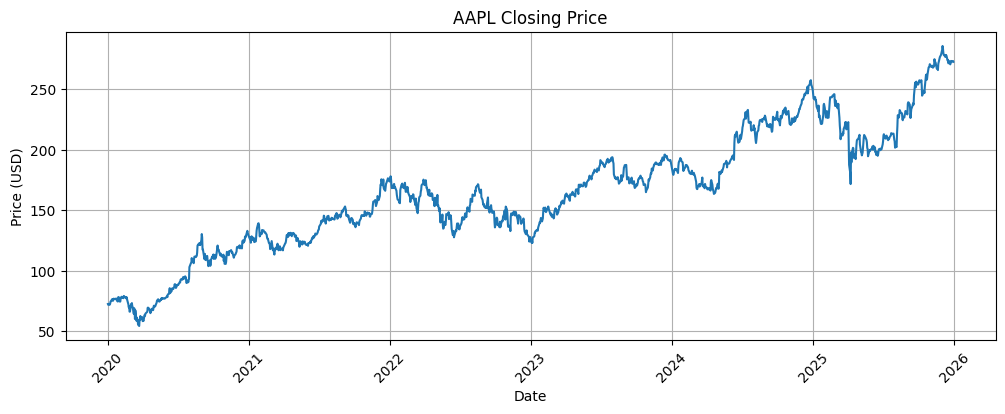

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(aapl.index, aapl["Close"])
plt.title("AAPL Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.grid()
plt.show()

## Comprehensive Example

Sample data: `./data/ni225_stock.pkl`, the Nikkei 225 index data from 2008 to 2024.

In [10]:
import sys

sys.path.append("..")

from src.utils import load_data, preprocess, get_array, rolling_norm_sequence

In [21]:
preprocess_kwargs = {
    "ma_windows": [5, 10, 20],
    "target_range": 5,
    "date_column": "date",
    "train_start": "2008-01-04",
    "val_start": "2020-01-01",
    "test_start": "2021-01-01",
    "test_end": "2024-12-30",
    "add_daily_norm": False,
    "norm_target": False,
}
FEATURES = ["open", "high", "low", "close", "volume", "trend_5", "trend_10", "trend_20"]
TARGET = "cumret_5"

In [12]:
data = load_data("../data/ni225_stock.pkl")
print(len(data))
print(type(data))
print(next(iter(data.items())))

225
<class 'dict'>
('4151.T',         Adj Close   Close    High     Low    Open   Volume        Date
0      846.131042  1180.0  1195.0  1158.0  1195.0  1608000  2008-01-04
1      820.316895  1144.0  1180.0  1144.0  1180.0  1254000  2008-01-07
2      838.243286  1169.0  1169.0  1144.0  1144.0  1505000  2008-01-08
3      831.072815  1159.0  1169.0  1159.0  1169.0  1225000  2008-01-09
4      822.468079  1147.0  1159.0  1147.0  1159.0  1265000  2008-01-10
...           ...     ...     ...     ...     ...      ...         ...
4174   2328.45459  2386.0  2396.5  2380.0  2395.0   345200  2024-12-24
4175  2322.111084  2379.5  2393.0  2369.0  2390.0   519100  2024-12-25
4176  2330.894287  2388.5  2388.5  2369.5  2370.0   825600  2024-12-26
4177  2355.591064  2384.5  2391.5  2360.0  2362.0   833300  2024-12-27
4178  2346.700195  2375.5  2396.0  2371.0  2384.5   679900  2024-12-30

[4179 rows x 7 columns])


In [19]:
train, valid, test = preprocess(data, **preprocess_kwargs)

In [20]:
print(len(train), len(valid), len(test))
print(next(iter(train.items())))
print(next(iter(valid.items())))
print(next(iter(test.items())))

209 209 209
('4151.T',         adj close   close    high     low    open   volume       date  \
0      846.131042  1180.0  1195.0  1158.0  1195.0  1608000 2008-01-04   
1      820.316895  1144.0  1180.0  1144.0  1180.0  1254000 2008-01-07   
2      838.243286  1169.0  1169.0  1144.0  1144.0  1505000 2008-01-08   
3      831.072815  1159.0  1169.0  1159.0  1169.0  1225000 2008-01-09   
4      822.468079  1147.0  1159.0  1147.0  1159.0  1265000 2008-01-10   
...           ...     ...     ...     ...     ...      ...        ...   
2952  2235.723145  2498.0  2539.0  2460.0  2523.0  1649700 2019-12-24   
2953   2270.62793  2537.0  2554.0  2520.0  2526.0   827400 2019-12-25   
2954  2284.947754  2553.0  2571.0  2541.0  2543.0   733300 2019-12-26   
2955  2294.878662  2542.0  2594.0  2539.0  2566.0  1100400 2019-12-27   
2956   2322.86499  2573.0  2588.0  2549.0  2559.0  1100800 2019-12-30   

           ret  next_ret   trend_5  trend_10  trend_20  cumret_5  
0            0 -0.030508         

In [ ]:
train_feat, train_label = get_array(train, FEATURES, TARGET, get_next_ret=False)
valid_feat, valid_label, valid_next_ret = get_array(
    valid, FEATURES, TARGET, get_next_ret=True
)
test_feat, test_label, test_next_ret = get_array(
    test, FEATURES, TARGET, get_next_ret=True
)

In [24]:
print(train_feat.shape, train_label.shape)
print(valid_feat.shape, valid_label.shape, valid_next_ret.shape)
print(test_feat.shape, test_label.shape, test_next_ret.shape)

(2957, 209, 8) (2957, 209, 1)
(242, 209, 8) (242, 209, 1) (242, 209, 1)
(980, 209, 8) (980, 209, 1) (980, 209, 1)


In [27]:
roll_train_feat, roll_train_label, _ = rolling_norm_sequence(
    train_feat,
    train_label,
    None,
    seq_len=20,
    norm_axis=0,
    norm_index=5,
    norm_type="std",
)
roll_valid_feat, roll_valid_label, roll_valid_next_ret = rolling_norm_sequence(
    valid_feat,
    valid_label,
    valid_next_ret,
    seq_len=20,
    norm_axis=0,
    norm_index=5,
    norm_type="std",
)
roll_test_feat, roll_test_label, roll_test_next_ret = rolling_norm_sequence(
    test_feat,
    test_label,
    test_next_ret,
    seq_len=20,
    norm_axis=0,
    norm_index=5,
    norm_type="std",
)

In [28]:
print(roll_train_feat.shape, roll_train_label.shape)
print(roll_valid_feat.shape, roll_valid_label.shape, roll_valid_next_ret.shape)
print(roll_test_feat.shape, roll_test_label.shape, roll_test_next_ret.shape)

(2938, 20, 209, 8) (2938, 209, 1)
(223, 20, 209, 8) (223, 209, 1) (223, 209, 1)
(961, 20, 209, 8) (961, 209, 1) (961, 209, 1)
